## Interior point method

In [11]:
import numpy as np
import pandas as pd
import copy as copy
import scipy
import scipy.io
import time
import os
from scipy.linalg import solve, LinAlgWarning
import warnings
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import random

from matplotlib.animation import FuncAnimation, PillowWriter
import openpyxl
import xlsxwriter

import importlib
from IPM_functions import (
    create_result_dataframes,
    update_result_dataframes,
    paso_intpoint,
    solve_catch_error,
    update_active_set_mask,
    active_set_diagnostics,
    progress_summary_df_clean,
    remove_rows_cols_K,
    build_reduced_system,
    load_lp_problem
)

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

# Método de puntos interiores (con heurística)

In [12]:
# Choose a file
mat_file = 'lp_kb2.mat'     # b = 0
#mat_file = 'lp_afiro.mat'   # bmax = 500, and no mu tends to zero  and no condition problem
#mat_file = 'lp_blend.mat'    # bmax = 26.32, and no mu tends to zero.
#mat_file = 'lp_fit1d.mat'   # b = 0
#mat_file = 'lp_fit1p.mat'   # bmax = 216, and no mu tends to zero, condition 10^12
#mat_file = 'lp_grow15.mat'  # b = 0, condition 10^6
#mat_file = 'lp_grow22.mat'  # b = 0, condition 1.4e7
#mat_file = 'lp_grow7.mat'   # b = 0, condition 1.2e7

# Load problem
Q, c, A, b, F, d, H = load_lp_problem(mat_file)
AT = A.T
FT = F.T

k = 0
n = Q.shape[0]
m = A.shape[0]
p = F.shape[0]

# Initial values
x = np.ones(n)
lamda = np.zeros(m)
mu = np.ones(p)
z = np.ones(p)
#z = F @ x - d + (0.5)*np.ones(p)

problem_info = {
    "problem_name": mat_file,
    "norm_inf_b": np.linalg.norm(b, np.inf),
    "dim_b": len(b),
    "num_zeros_b": np.sum(b==0),
    "dim_x": n,
    "dim_eq": m,
    "dim_ineq": p
}

tol = 1e-7
kmax = 100

sigma = 0.5
M_c = np.dot(mu, z) / p
tau = sigma * M_c

sigmas = [sigma]
alphas = []

obj_function_value = 0.5 * x @ Q @ x + c @ x
max_complementarity_value = np.max(mu * z)
mu_pct_init = np.zeros(p)
z_pct_init  = np.zeros(p)

#Define and initialise the dataframes that will be used to record the results on every iteration for mu, z, tau, the maximum complementarity value: max(mu_i * z_i), and the objective value
(mu_df, z_df, tau_df, mu_pct_df, z_pct_df,
 obj_function_df, max_complementarity_df, active_set_history) = create_result_dataframes(p)

(mu_df, z_df, tau_df, mu_pct_df, z_pct_df,
 obj_function_df, max_complementarity_df, active_set_history) = update_result_dataframes(
    k, mu, z, tau,
    mu_pct_init, z_pct_init,
    obj_function_value, max_complementarity_value, p,
    mu_df, z_df, tau_df,
    mu_pct_df, z_pct_df,
    obj_function_df, max_complementarity_df,
    active_set_history,
)

regression_df = pd.DataFrame(columns=active_set_history.columns) #Store any regressed indexes for mu

while k < kmax:

    # Define and update diagonal matri¡ces D_z and D_mu inside the loop
    D_z = np.diag(z)
    D_mu = np.diag(mu)

    r_x = Q @ x - AT @ lamda - FT @ mu + c
    r_lamda = - A @ x + b
    r_mu = -F @ x + d + z
    r_z = np.multiply(mu, z) #Equivalent to D_z*D_mu @ np.ones(p)

    F_x = np.concatenate((r_x, r_lamda, r_mu, r_z), 0)
    KKT_norm = np.linalg.norm(F_x, np.inf)

    if KKT_norm < tol:
        print("CNPO norm is below the tolerance, stopping iterations.")
        cnpo_norm = KKT_norm
        primal_residual_norm            = np.linalg.norm(r_lamda, np.inf)
        inequality_residual_norm        = np.linalg.norm(r_mu, np.inf)
        max_complementarity             = np.max(r_z)
        barrier_parameter               = tau
        cond_new_K                      = 1/np.linalg.cond(K,1)
        objective_value                 =  0.5 * x @ Q @ x + c @ x
        break

    red_mu = []

    # Build the PROPER REDUCED system we will use for calculating
    row1 = np.hstack((Q, -AT, -FT @ D_mu))
    row2 = np.hstack((-A, np.zeros((m, m + p))))
    row3 = np.hstack((-D_mu @ F, np.zeros((p, m)), -np.diag(mu * z)))

    K = np.vstack((row1, row2, row3))

    L = np.concatenate((
        r_x ,   # dual residual
        r_lamda,                          # primal residual
        D_mu @ (d - F @ x) + tau               # complementarity row
    ))
    
    #print("reduced system condition number:", np.linalg.cond(K,1))

    # Solve the linear system and catch any ill-conditioning warnings from SciPy
    delta_vector = solve_catch_error(K,-L,k) # Reduced system to n+m+p dimensions

    delta_x     = delta_vector[:n] # should be the same ?
    delta_lamda = delta_vector[n:n + m] # should be the same ?
    Ddelta_mu    = delta_vector[n + m:]
    
    delta_mu = D_mu @ Ddelta_mu  # Divide each element of delta_mu1 by the corresponding diagonal element of D_mu

    # Reconstruct Δz from the 3rd KKT row (primal feasibility)
    # δz = F δx + (Fx - d - z)  == F @ delta_x - r_mu  (since r_mu = -F@x + d + z)
    delta_z = F @ delta_x + F@x - d - z
    
    ### Step size reduction
    alpha_mu = paso_intpoint(mu, delta_mu)
    alpha_z  = paso_intpoint(z, delta_z)
    alpha    = min(alpha_mu, alpha_z)
    #alpha    = 0.995 * min(alpha_mu, alpha_z) # From Javi's thesis
    alphas.append(alpha)

    if alpha >= 0.9:
        sigma = max(10**-4,sigma/4)
    
    if alpha <= 0.75 and sigma < 0.5:
        sigma = min(0.5,sigma*4)
    
    # Percentage changes before we udpate mu and z
    mu_percentage_change = alpha*delta_mu/mu #(delta_mu(k) divided by mu_k-1 #mu_percentage_change = delta_mu/mu # (mu_pct_change = delta_mu(k) divided by mu_k-1, #mu_pct_change = delta_mu(k) divided by mu_k-1, # delta_mu(k)  = mu_pct_change*(mu_k-1)
    z_percentage_change  = alpha*delta_z/z
    
    # Update variables
    x += alpha * delta_x
    mu += alpha * delta_mu
    lamda += alpha * delta_lamda
    z += alpha * delta_z
    
    # Update tau and residuals
    M_c = np.dot(mu, z) / p
    tau = sigma * M_c
    k += 1
    print("the sigma that was used for calculation iter", k , "is", sigma)
    print("the alpha that was calculated from iter", k , "is", alpha)
    sigmas.append(sigma)

    # Recalculate the objective function value and maximum complementarity value for this iteration
    obj_function_value = 0.5 * x @ Q @ x + c @ x
    max_complementarity_value = np.max(mu * z)

    #Update the dataframes that record the values for each iteration
    (mu_df, z_df, tau_df, mu_pct_df, z_pct_df,
 obj_function_df, max_complementarity_df, active_set_history) = update_result_dataframes(
    k, mu, z, tau,
    mu_percentage_change, z_percentage_change,
    obj_function_value, max_complementarity_value, p,
    mu_df, z_df, tau_df,
    mu_pct_df, z_pct_df,
    obj_function_df, max_complementarity_df,
    active_set_history,
)

    # Review if mu and z have been meeting the criteria we want (for the last 3 iterations) in order to
    # eliminate them when we start our experiment.
    
    active_set_history = update_active_set_mask(mu, z, Q, k, tau, active_set_history, mu_df, mu_percentage_change, z_percentage_change)
    # Recompute the highlighted columns for the next reduced iteration and see if any components stopped meeting the criteria, although it was meeting it before

    # We save these values again because we're saving them separately so we can update the original variables once we run the heuristic/experiment
    # This allows us to save relevant values of the regular IPM method.

    #------ This sections is used for reference, but not used for any calculations -------#
    #------ This checks how many of if all components of the complementarity are below a set tolerance (Courtesy of Andreas), and if indices are a subset of the previous indices

    # Create a boolean mask that checks if all components of the complementarity are below a set tolerance
    mask = mu*z <= 1e-5
    
    #print('cuantos chicos mu*z = %g, vector\n' % (sum(mask)), (mu*z)[mask])
    
    #If all values of mu*z are below the tolerance, we check if the indices that fulfil this are a subset of the previous indices that fulfilled this
    if all(mask): #Return True only if EVERY entry in mask is True
        # Once the mu and z have gotten sufficiently small,

        #neg_mu_mask = (-0.52 < mu_percentage_change) & (mu_percentage_change < -0.48)
        #const_z_mask = (-0.01 < z_percentage_change) & (z_percentage_change < 0.01)
        grow_z_mask = (z_percentage_change > -0.03) #& (z_percentage_change < 0.01)
        neg_mu = np.arange( len(mask) )[grow_z_mask]
        
        #print('mus chicos: vector\n', mu[neg_mu])
        if set(red_mu).issubset( neg_mu ):
            print ('IS subset: GOOD')
        else:
            print ('FAILS subset condition: BAD')
            
        #print('mus chicos: vector\n', neg_mu)
        #print('  change in percentages for mu \n', mu_percentage_change[neg_mu] )
        #print('zs tending to positive contants\n', z[neg_mu] )
        #print('  Largest and smallest change for percentages in entries of z  \n', min(z_percentage_change[neg_mu]), max(z_percentage_change[neg_mu] ))
        red_mu = neg_mu.copy()

print("Número de iteraciones hasta el criterio de paro:",k)
problem_results_before_heuristic = {
    "KKT residual (‖r‖∞)": cnpo_norm,
    "Primal residual (‖r_p‖∞)": primal_residual_norm,
    "Inequality residual (‖r_d‖∞)": inequality_residual_norm,
    "Complementarity gap (max μᵢ zᵢ)": max_complementarity,
    "Barrier parameter (τ)": barrier_parameter,
    "Condition number κ(K)": cond_new_K,
    "Objective value f(x)": objective_value
}

summary_before = progress_summary_df_clean(problem_results_before_heuristic)
display(summary_before)

Loading problem from: lp_kb2.mat
Norma infinita de b:  0.0
Problem loaded. n=68, m=43, p=68
Number of zeros in b: 43 (100.00%)
the sigma that was used for calculation iter 1 is 0.5
the alpha that was calculated from iter 1 is 0.24859949444843918
the sigma that was used for calculation iter 2 is 0.5
the alpha that was calculated from iter 2 is 0.8282120752694667
the sigma that was used for calculation iter 3 is 0.5
the alpha that was calculated from iter 3 is 0.6020960126351879
the sigma that was used for calculation iter 4 is 0.5
the alpha that was calculated from iter 4 is 0.34232011666879403
the sigma that was used for calculation iter 5 is 0.5
the alpha that was calculated from iter 5 is 0.5151254840474289
the sigma that was used for calculation iter 6 is 0.5
the alpha that was calculated from iter 6 is 0.684826312088805
the sigma that was used for calculation iter 7 is 0.5
the alpha that was calculated from iter 7 is 0.7602948728303245
the sigma that was used for calculation iter 8

,Metric,Before
0,KKT residual (‖r‖∞),1.899666e-08
1,Primal residual (‖r_p‖∞),5.285486e-17
2,Inequality residual (‖r_d‖∞),0.000000e+00
3,Complementarity gap (max μᵢ zᵢ),1.899666e-08
4,Barrier parameter (τ),2.764343e-10
5,Condition number κ(K),3.211980e-12
6,Objective value f(x),-2.082925e-02


In [ ]:
stable_active_indices, regressed_indices = active_set_diagnostics(active_set_history,regression_df,p)

K1, D_mu1, L1 = remove_rows_cols_K(Q, AT, FT, D_mu, A, F, D_z, mu, z, x, lamda, c, b, d, tau, stable_active_indices,r_x, r_lamda)
                   
print(K.shape, "condition number K:", np.linalg.cond(K, 1))
print(K1.shape, "condition number K1:", np.linalg.cond(K1, 1))
print("condition number improvement:", np.linalg.cond(K, 1)/np.linalg.cond(K1, 1))

delta_vector = scipy.linalg.solve(K1, -L1)
delta_x     = delta_vector[:n] # should be the same ?
delta_lamda = delta_vector[n:n + m] # should be the same ?
Ddelta_mu    = delta_vector[n + m:]

delta_mu_reduced = D_mu1 @ Ddelta_mu  # Divide each element of delta_mu1 by the corresponding diagonal element of U

# Here's the vector transformed back into the original size problem
delta_mu = np.zeros_like(mu)
active_indices = [i for i in range(p) if i not in stable_active_indices]
for i, idx in enumerate(active_indices):
    delta_mu[idx] = delta_mu_reduced[i]

# Reconstruct Δz from the 3rd KKT row (primal feasibility)
# δz = F δx - (Fx - d - z)  == F @ delta_x - r_mu  (since r_mu = -F@x + d + z)
delta_z = F @ delta_x - (F @ x - d - z)

# Recompute step sizes for the reduced-step directions **DOUBLE CHECK THIS LATER
alpha_mu = paso_intpoint(mu, delta_mu)   # ensures μ + α·Δμ ≥ (1-τ)μ > 0
alpha_z  = paso_intpoint(z,  delta_z)    # ensures z + α·Δz ≥ (1-τ)z > 0
alpha    = min(alpha_mu, alpha_z)
print("alpha", alpha)

# Percentage changes before we udpate mu and z
mu_percentage_change = alpha*delta_mu/mu
z_percentage_change  = alpha*delta_z/z

# Update variables
x += alpha * delta_x
mu += alpha * delta_mu
lamda += alpha * delta_lamda
z += alpha * delta_z

# Update tau and residuals
M_c = np.dot(mu, z) / p
tau = sigma * M_c
k += 1

# Recalculate the objective function value and maximum complementarity value for this iteration
obj_function_value = 0.5 * x @ Q @ x + c @ x
max_complementarity_value = np.max(mu * z)

#Update the dataframes that record the values for each iteration
(mu_df, z_df, tau_df, mu_pct_df, z_pct_df,
 obj_function_df, max_complementarity_df, active_set_history) = update_result_dataframes(
    k, mu, z, tau,
    mu_percentage_change, z_percentage_change,
    obj_function_value, max_complementarity_value, p,
    mu_df, z_df, tau_df,
    mu_pct_df, z_pct_df,
    obj_function_df, max_complementarity_df,
    active_set_history,
)

# Review if mu and z have been meeting the criteria we want (for the last 3 iterations) in order to
# eliminate them when we start our experiment.

active_set_history = update_active_set_mask(mu, z, Q, k, tau, active_set_history, mu_df, mu_percentage_change, z_percentage_change)

Consistently highlighted in last 5 iterations: [3, 5, 6, 9, 10, 11, 15, 16, 18, 21, 23, 25, 27, 30, 34, 41, 48, 49, 56, 58, 59, 61, 62, 63, 64, 65, 66, 67]
How many in percentage of mu's dimension?  41.17647058823529 %
Deleted 28 rows/columns. K1 shape: (151, 151)
(179, 179) condition number K: 311334444015.0081
(151, 151) condition number K1: 1914664240970.4958
condition number improvement: 0.1626052429209209
alpha 1.0
[Iteration 22] Index 3 stopped meeting at least one criteria to be considered as zero:
mu_percentage_change_3 is 0.00e+00
z_percentage_change_3 is 5.02e-05
   - μ did not decrease AT ALL (current: 1.72e-06, previous: 1.72e-06)
   - z_3 is 4.97e-03
[Iteration 22] Index 5 stopped meeting at least one criteria to be considered as zero:
mu_percentage_change_5 is 0.00e+00
z_percentage_change_5 is 5.49e-05
   - μ did not decrease AT ALL (current: 1.90e-06, previous: 1.90e-06)
   - z_5 is 4.50e-03
[Iteration 22] Index 6 stopped meeting at least one criteria to be considered as

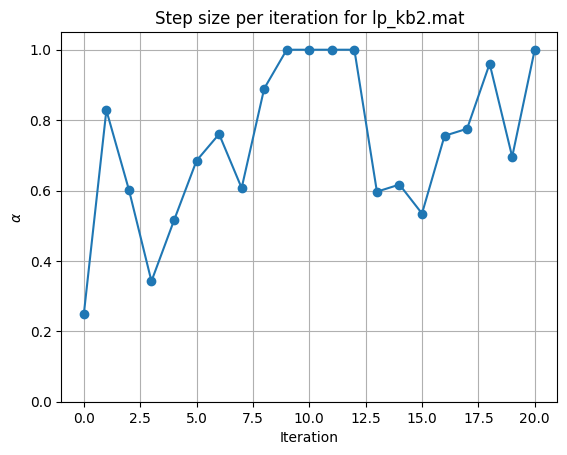

In [14]:
plt.plot(alphas, marker='o')
plt.xlabel('Iteration')
plt.ylabel(r'$\alpha$')
plt.title(f"Step size per iteration for {mat_file}")
plt.ylim(0, 1.05)
plt.grid(True)
plt.show()

In [15]:
print("z_1", z[0])
print("mu_1", mu[0])
print("tau", tau)
print("M_c", M_c)
print("delta_z_1", delta_z[0])
print("delta_mu_1", delta_mu[0])
print("alpha", alpha)
print("sigma", sigma)
print("k", k)

z_1 0.001328461780006951
mu_1 2.1025210587898698e-07
tau 1.1394865552666233e-10
M_c 3.6463569768531944e-09
delta_z_1 -4.6075093191909076e-07
delta_mu_1 -6.245373722158624e-06
alpha 1.0
sigma 0.03125
k 22


In [16]:
z_df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67
0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
1,0.978628,0.908670,0.961381,0.914983,0.902602,0.907010,0.978422,0.927459,0.943686,0.915938,0.906778,0.900577,0.871096,0.916485,0.825883,0.750289,0.918505,0.762318,0.976614,0.940699,0.924446,0.969402,0.940894,0.914036,0.739004,0.981263,0.940648,0.827138,0.780888,0.873044,0.620272,0.745230,0.920629,0.493801,0.781135,0.775993,0.878109,0.640442,0.745526,0.907772,0.531529,0.836226,0.792638,0.879971,0.620126,0.745470,0.900131,0.487472,0.755532,0.941698,0.846718,1.128323,0.378039,0.733426,1.225731,0.010000,0.755532,0.742520,0.752599,0.752103,0.767590,0.753632,1.021710,0.876264,0.995931,0.855459,1.064560,0.882303
2,0.776710,0.675026,0.762631,0.714868,0.703143,0.702172,0.765711,0.702411,0.741817,0.744516,0.666504,0.714312,0.606387,0.681448,0.506909,0.306564,0.833863,0.236912,0.701661,0.725576,0.813434,0.726315,0.726674,0.825786,0.197926,0.709318,0.725999,0.176814,0.072725,0.097688,0.098789,0.120181,0.204272,0.135732,0.156345,0.112327,0.118454,0.114326,0.119839,0.166931,0.116889,0.169947,0.081578,0.087735,0.109297,0.120174,0.209495,0.130242,0.138150,0.244944,0.008467,0.045714,0.064249,0.102030,0.322535,0.124700,0.138150,0.025721,0.131711,0.130623,0.068561,0.133978,0.846715,0.705156,0.789157,0.677495,0.960670,0.730968
3,0.591245,0.523290,0.566130,0.551367,0.480568,0.527009,0.597035,0.522374,0.542763,0.576493,0.497145,0.521818,0.300903,0.410116,0.183945,0.048289,0.657511,0.051177,0.559779,0.609198,0.653681,0.575517,0.607811,0.646221,0.047165,0.572969,0.606203,0.127257,0.038369,0.043489,0.027009,0.044676,0.029749,0.053251,0.085343,0.045122,0.049708,0.037998,0.043751,0.056611,0.043502,0.130090,0.055727,0.033211,0.038360,0.044829,0.023931,0.041330,0.066071,0.239966,0.036494,0.023684,0.000642,0.030533,0.007566,0.035358,0.066071,0.058798,0.055628,0.053863,0.069061,0.059305,0.762102,0.513138,0.620825,0.510533,0.980073,0.576133
4,0.466573,0.430060,0.451050,0.455980,0.413862,0.440224,0.461857,0.415469,0.425365,0.495869,0.442663,0.457477,0.179644,0.270251,0.100540,0.036945,0.584275,0.035774,0.502232,0.523981,0.587169,0.516841,0.523736,0.577253,0.033549,0.515512,0.515558,0.087406,0.022387,0.021192,0.019586,0.027481,0.026618,0.036356,0.050429,0.026931,0.032339,0.027256,0.026722,0.043732,0.031726,0.090741,0.036836,0.014266,0.027907,0.027649,0.023024,0.024541,0.049532,0.161017,0.018595,0.000237,0.007190,0.014293,0.025815,0.025063,0.049532,0.039551,0.038348,0.036458,0.048471,0.042286,0.669585,0.455460,0.485947,0.468966,0.942008,0.578773


In [17]:
mu_df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67
0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
1,0.897072,0.967030,0.914319,0.960717,0.973098,0.968690,0.897278,0.948242,0.932014,0.959762,0.968922,0.975123,1.004604,0.959215,1.049817,1.125411,0.957195,1.113382,0.899086,0.935001,0.951254,0.906298,0.934806,0.961664,1.136696,0.894437,0.935052,1.048562,1.094813,1.002656,1.255429,1.130470,0.955072,1.381900,1.094565,1.099707,0.997591,1.235259,1.130174,0.967928,1.344172,1.039475,1.083062,0.995729,1.255574,1.130230,0.975569,1.388229,1.120168,0.934002,1.028982,0.747377,1.497662,1.142274,0.649969,1.865700,1.120168,1.133180,1.123102,1.123597,1.108110,1.122069,0.853990,0.999436,0.879769,1.020241,0.811140,0.993397
2,0.693598,0.796459,0.706848,0.754209,0.766455,0.767561,0.703687,0.766940,0.727004,0.723156,0.805672,0.754313,0.876008,0.789208,1.005754,1.321162,0.630241,1.413594,0.762709,0.743132,0.652817,0.740727,0.742036,0.637496,1.496843,0.754985,0.742713,1.423854,1.625070,1.459970,1.830300,1.607758,1.283954,1.941808,1.507522,1.576383,1.429362,1.768495,1.607865,1.338277,1.931992,1.421542,1.595209,1.461641,1.809255,1.607436,1.301414,1.967284,1.566824,1.219809,1.605072,1.152869,2.417846,1.652481,0.873550,13.603471,1.566824,1.755686,1.580322,1.582616,1.651331,1.575555,0.632430,0.762652,0.682033,0.792936,0.544296,0.734135
3,0.585463,0.661476,0.609901,0.628905,0.706502,0.656020,0.580938,0.660821,0.634983,0.601029,0.692947,0.659844,0.974145,0.792237,1.261411,2.003232,0.518062,2.142346,0.616957,0.568886,0.525332,0.602369,0.570399,0.527593,2.300286,0.603065,0.571990,1.597576,2.950751,2.534750,3.189251,2.579557,2.154856,2.775859,1.999150,2.565144,2.341580,2.861747,2.593024,2.086295,2.937645,1.556508,2.509921,2.763520,2.916495,2.577201,2.203954,2.983711,2.249737,0.966330,8.522247,3.458537,5.094869,2.910635,1.547079,16.055202,2.249737,2.784935,2.390043,2.415165,2.274758,2.339054,0.446811,0.669593,0.558456,0.675850,0.321895,0.600482
4,0.573683,0.626536,0.593170,0.592316,0.642913,0.612609,0.578155,0.643624,0.625965,0.546191,0.609198,0.589180,1.161318,0.885192,1.611074,2.586159,0.457036,2.806811,0.538032,0.516985,0.457909,0.524544,0.517446,0.462932,2.994031,0.524361,0.525289,1.853818,4.174148,3.852824,4.400851,3.551985,2.939466,3.430050,2.584232,3.575271,3.133524,3.705347,3.595494,2.527493,3.613142,1.790733,3.193127,4.554381,3.717484,3.542314,3.143439,4.106855,2.626059,1.114059,10.840754,7.325758,11.409713,4.724563,2.379712,16.323850,2.626059,3.398669,3.007107,3.084335,2.732311,2.859438,0.398669,0.590747,0.550690,0.575007,0.263529,0.459067


In [18]:
len(alphas)

21

In [19]:
import pandas as pd

# Average complementarity each iteration
Mc = (mu_df * z_df).mean(axis=1)

# Average mu and z each iteration
mu_mean = mu_df.mean(axis=1)
z_mean  = z_df.mean(axis=1)

table = pd.DataFrame({
    "mu_mean":  mu_mean,
    "z_mean":   z_mean,
    "Mc":       Mc,
    "sigma":    sigmas,
    "tau":      sigmas * Mc,
    "alpha":    [None]*(len(sigmas)-len(alphas)) + alphas  # Pad with None if alphas is shorter than sigmas
})

# Aggregate σ-tracking check
table["Mc_next_predicted"] = table["sigma"] * table["Mc"]
table["Mc_next_actual"]    = table["Mc"].shift(-1)
table["ratio (actual/predicted)"] = table["Mc_next_actual"] / table["Mc_next_predicted"]

# Per-iteration shrinkage of each mean (how fast is the average mu / z going down?)
table["mu_shrink_factor"] = table["mu_mean"].shift(-1) / table["mu_mean"]   # next/current
table["z_shrink_factor"]  = table["z_mean"].shift(-1)  / table["z_mean"]

print(table.to_string())

ValueError: operands could not be broadcast together with shapes (22,) (23,) 

In [ ]:
delta_mu

array([-2.13157876e-05,  4.55688224e-05, -4.29448846e-05, -2.62033067e-06,
       -5.29011847e-06, -2.99090977e-06, -1.21909073e-06, -5.98215459e-04,
       -2.67844569e-07, -1.16150422e-06, -2.58719780e-06, -1.64270355e-06,
       -1.90601829e-05, -1.58523197e-04, -7.24248507e-04, -6.56129923e-07,
       -3.67976326e-06, -3.53997755e-07, -3.31604497e-06, -3.70754901e-05,
       -7.87362035e-06, -5.58276405e-06,  2.49927928e-05, -2.14755201e-06,
       -2.35879336e-07, -1.79662678e-06,  2.07196027e-04, -2.58216038e-05,
        3.43985032e-03,  3.72047113e-04, -3.03645947e-07, -4.21056569e-04,
        7.98674246e-04,  1.56755393e-03, -1.41414933e-05, -1.13430427e-03,
       -6.02996942e-04, -2.25246880e-07,  1.01589877e-03, -2.62222294e-04,
       -3.93828610e-04, -8.00585507e-06, -2.06079433e-02, -7.08890187e-03,
       -2.55304194e-07,  1.10625717e-02, -6.33654580e-03, -1.04369884e-02,
       -1.09563390e-05, -5.34971496e-06, -4.17103472e-03, -6.43447835e-04,
       -1.21975836e-06,  

In [ ]:
mu_pct_df

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67
Iteration,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,-0.414032,-0.132624,-0.344656,-0.158017,-0.108214,-0.125945,-0.413203,-0.208200,-0.273476,-0.161859,-0.125012,-0.100069,0.018520,-0.164059,0.200391,0.504471,-0.172183,0.456084,-0.405929,-0.261462,-0.196082,-0.376919,-0.262245,-0.154209,0.549866,-0.424632,-0.261256,0.195342,0.381387,0.010684,1.027470,0.524819,-0.180726,1.536204,0.380392,0.401075,-0.009690,0.946336,0.523629,-0.129009,1.384442,0.158788,0.334121,-0.017179,1.028055,0.523855,-0.098275,1.561662,0.483381,-0.265478,0.116583,-1.016185,2.001861,0.572302,-1.408010,3.482309,0.483381,0.535723,0.495180,0.497175,0.434877,0.491026,-0.587331,-0.002269,-0.483634,0.081422,-0.759695,-0.026562
2,-0.273868,-0.212972,-0.273979,-0.259538,-0.256403,-0.250697,-0.260506,-0.230856,-0.265590,-0.297660,-0.203434,-0.273413,-0.154558,-0.213998,-0.050677,0.210016,-0.412426,0.325569,-0.183146,-0.247771,-0.378805,-0.220583,-0.248987,-0.407010,0.382554,-0.188250,-0.248365,0.432149,0.584798,0.550707,0.552888,0.509777,0.415780,0.489214,0.455535,0.523365,0.522588,0.521219,0.510341,0.461982,0.528017,0.443797,0.570952,0.564964,0.532447,0.509797,0.403285,0.503637,0.481447,0.369474,0.675990,0.655090,0.741856,0.539305,0.415336,7.596301,0.481447,0.663289,0.491547,0.493263,0.591905,0.487981,-0.313254,-0.286060,-0.271378,-0.269008,-0.397210,-0.315119
3,-0.258935,-0.281482,-0.227796,-0.275934,-0.129914,-0.241353,-0.289716,-0.229810,-0.210225,-0.280489,-0.232379,-0.208005,0.186063,0.006373,0.422181,0.857446,-0.295623,0.856227,-0.317388,-0.389431,-0.324341,-0.310229,-0.384167,-0.286329,0.891483,-0.334202,-0.381773,0.202639,1.354881,1.222671,1.233149,1.003899,1.126559,0.713379,0.541635,1.041751,1.059963,1.026717,1.017633,0.928326,0.864524,0.157689,0.952359,1.479328,1.016427,1.001999,1.151821,0.858112,0.723901,-0.345132,7.157620,3.321630,1.838898,1.264537,1.280569,0.299335,0.723901,0.973660,0.850989,0.873712,0.627026,0.804840,-0.487467,-0.202658,-0.300932,-0.245247,-0.678634,-0.302369
4,-0.058778,-0.154306,-0.080132,-0.169954,-0.262928,-0.193308,-0.013993,-0.076020,-0.041486,-0.266535,-0.353060,-0.312839,0.561288,0.342757,0.809768,0.850061,-0.344113,0.906045,-0.373706,-0.266515,-0.374919,-0.377418,-0.271193,-0.358021,0.881020,-0.381246,-0.238508,0.468550,1.211162,1.519052,1.109783,1.101234,1.063660,0.688453,0.854947,1.150356,0.987991,0.861138,1.129360,0.617769,0.671726,0.439590,0.795167,1.893070,0.802293,1.093950,1.245247,1.099628,0.488647,0.446589,0.794734,3.266436,3.620738,1.820539,1.572203,0.048880,0.488647,0.643774,0.754210,0.809389,0.587589,0.649906,-0.314749,-0.343985,-0.040622,-0.435877,-0.529683,-0.687963
5,0.034769,0.005418,0.030360,-0.154407,-0.185730,-0.164829,0.101815,0.063849,0.093575,-0.264821,-0.340465,-0.302151,0.798805,0.552694,0.800308,0.735896,-0.298284,0.830615,-0.312976,-0.266644,-0.326762,-0.321291,-0.287837,-0.323852,0.782006,-0.316029,-0.227906,0.401149,1.095181,1.186072,1.156501,1.078362,1.029096,0.727357,0.875520,1.069882,0.513338,0.890946,1.113774,0.747405,0.598728,0.391681,0.809156,1.270436,0.933811,1.063273,1.131836,0.973844,0.351421,0.385160,0.895806,1.797808,1.677266,2.251858,1.131833,0.076947,0.351421,0.51655

In [ ]:
mu_df

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67
0,1.000000,1.000000,1.000000,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000,1.000000,1.000000,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000,1.000000e+00,1.000000e+00,1.000000,1.000000e+00,1.000000e+00,1.000000e+00,1.000000,1.000000,1.000000,1.000000,1.000000e+00,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000e+00,1.000000,1.000000,1.000000,1.000000e+00,1.000000,1.000000,1.000000e+00,1.000000,1.000000,1.000000,1.000000,1.000000e+00,1.000000,1.000000,1.000000e+00,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
1,0.897072,0.967030,0.914319,9.607171e-01,9.730980e-01,9.686902e-01,8.972778e-01,0.948242,9.320141e-01,9.597618e-01,9.689220e-01,9.751230e-01,1.004604,0.959215,1.049817,1.125411e+00,9.571955e-01,1.113382e+00,8.990862e-01,0.935001,9.512542e-01,9.062982e-01,0.934806,9.616638e-01,1.136696e+00,8.944368e-01,0.935052,1.048562,1.094813,1.002656,1.255429e+00,1.130470,0.955072,1.381900,1.094565,1.099707,0.997591,1.235259e+00,1.130174,0.967928,1.344172,1.039475e+00,1.083062,0.995729,1.255574e+00,1.130230,0.975569,1.388229,1.120168,9.340022e-01,1.028982,0.747377,1.497662e+00,1.142274,0.649969,1.865700,1.120168,1.133180,1.123102,1.123597,1.108110,1.122069,8.539898e-01,9.994360e-01,8.797688e-01,1.020241e+00,8.111401e-01,9.933968e-01
2,0.693598,0.796459,0.706848,7.542087e-01,7.664548e-01,7.675607e-01,7.036865e-01,0.766940,7.270037e-01,7.231562e-01,8.056720e-01,7.543127e-01,0.876008,0.789208,1.005754,1.321162e+00,6.302406e-01,1.413594e+00,7.627095e-01,0.743132,6.528166e-01,7.407272e-01,0.742036,6.374957e-01,1.496843e+00,7.549846e-01,0.742713,1.423854,1.625070,1.459970,1.830300e+00,1.607758,1.283954,1.941808,1.507522,1.576383,1.429362,1.768495e+00,1.607865,1.338277,1.931992,1.421542e+00,1.595209,1.461641,1.809255e+00,1.607436,1.301414,1.967284,1.566824,1.219809e+00,1.605072,1.152869,2.417846e+00,1.652481,0.873550,13.603471,1.566824,1.755686,1.580322,1.582616,1.651331,1.575555,6.324301e-01,7.626517e-01,6.820335e-01,7.929363e-01,5.442959e-01,7.341351e-01
3,0.585463,0.661476,0.609901,6.289055e-01,7.065023e-01,6.560204e-01,5.809377e-01,0.660821,6.349826e-01,6.010285e-01,6.929470e-01,6.598435e-01,0.974145,0.792237,1.261411,2.003232e+00,5.180620e-01,2.142346e+00,6.169572e-01,0.568886,5.253316e-01,6.023687e-01,0.570399,5.275930e-01,2.300286e+00,6.030654e-01,0.571990,1.597576,2.950751,2.534750,3.189251e+00,2.579557,2.154856,2.775859,1.999150,2.565144,2.341580,2.861747e+00,2.593024,2.086295,2.937645,1.556508e+00,2.509921,2.763520,2.916495e+00,2.577201,2.203954,2.983711,2.249737,9.663301e-01,8.522247,3.458537,5.094869e+00,2.910635,1.547079,16.055202,2.249737,2.784935,2.390043,2.415165,2.274758,2.339054,4.468107e-01,6.695934e-01,5.584558e-01,6.758498e-01,3.218950e-01,6.004822e-01
4,0.573683,0.626536,0.593170,5.923165e-01,6.429132e-01,6.126094e-01,5.781551e-01,0.643624,6.259650e-01,5.461906e-01,6.091977e-01,5.891802e-01,1.161318,0.885192,1.611074,2.586159e+00,4.570358e-01,2.806811e+00,5.380318e-01,0.516985,4.579093e-01,5.245439e-01,0.517446,4.629324e-01,2.994031e+00,5.243605e-01,0.525289,1.853818,4.174148,3.852824,4.400851e+00,3.551985,2.939466,3.430050,2.584232,3.575271,3.133524,3.705347e+00,3.595494,2.527493,3.613142,1.790733e+00,3.193127,4.554381,3.717484e+00,3.542314,3.143439,4.106855,2.626059,1.114059e+00,10.840754,7.325758,1.140971e+01,4.724563,2.379712,16.323850,2.626059,3.398669,3.007107,3.084335,2.732311,2.859438,3.986691e-01,5.907467e-01,5.506900e-01,5.750067e-01,2.635286e-01,4.590666e-01
5,0.583958,0.628284,0.602447,5.452043e-01,5.814031e-01,5.605942e-01,6.084778e-01,0.664793,6.561383e-01,4.716816e-01,5.023553e-01,4.974768e-01,1.639182,